In [1]:
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Overview
- Urban Neighboorhood differ in - food accessibility, healthcare & transit connectivity, greenery, shopping density, educational infrastructure.
- Raw POI is difficult to interpret directly.
- Objective: Determine whether neighboorhoods can automatically be segmented into meaninful lifestyle tiers using unsupervised learning.

# Unsupervised machine learning
- Preferred technique: KMeans - computationally efficient, easy to interpret, predictable cluster counts, strong visualization support and would be suitable for structured city zoning.
- Other approaches considered - DBSCAN (sensitive to epsilon parameter, unstable across cities with varying density), HDBSCAN (implementation complexity, harder to interpret)

# Data
- API source: Geoapify Places API

In [ ]:
API_KEY = "#"

CITY_BBOXES = {
    "Pune": {
        "lat_min": 18.40,
        "lat_max": 18.65,
        "lon_min": 73.72,
        "lon_max": 74.05,
    }
}

AMENITIES = {
    "food": "catering.restaurant",
    "health": "healthcare.hospital",
    "green": "leisure.park",
    "education": "education.school",
    "finance": "service.financial.bank",
    "shopping": "commercial.supermarket",
    "transit": "public_transport"
}

bbox = CITY_BBOXES["Pune"]
all_rows = []

for category_name, api_category in AMENITIES.items():
    bbox_str = (
        f"{bbox['lon_min']},{bbox['lat_min']},"
        f"{bbox['lon_max']},{bbox['lat_max']}"
    )

    url = (
        f"https://api.geoapify.com/v2/places"
        f"?categories={api_category}"
        f"&filter=rect:{bbox_str}"
        f"&limit=300"
        f"&apiKey={API_KEY}"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Failed for {category_name}")
        continue

    data = response.json()

    features = data.get("features", [])

    print(f"Fetched {len(features)} records for {category_name}")

    for feature in features:
        props = feature.get("properties", {})
        all_rows.append({
            "name": props.get("name"),
            "lat": props.get("lat"),
            "lon": props.get("lon"),
            "category": category_name,
            "place_id": props.get("place_id")
        })

raw_df = pd.DataFrame(all_rows)

print(raw_df.shape)
raw_df.head()

Fetched 300 records for food
Fetched 300 records for health
Fetched 300 records for green
Fetched 300 records for education
Fetched 300 records for finance
Fetched 226 records for shopping
Fetched 300 records for transit
(2026, 5)


,name,lat,lon,category,place_id
0,Kondhana Pure Veg Family Garden & Restaurants,18.428276,73.755796,food,5105bc71f75e70524059952d9276a36d3240f00103f901...
1,Wellness Club,18.446998,73.900403,food,51430d9535a0795240596edc627e6e723240f00103f901...
2,jyoti,18.464561,73.879223,food,51dd39de2e457852405992fd987bed763240f00103f901...
3,Real Taste,18.468368,73.889149,food,5166321ccfe778524059847c75fae6773240f00103f901...
4,Hotel Gavkari,18.459754,73.979327,food,515405fe4bad7e5240593436cf6cb2753240f00103f901...


In [3]:
print(data.keys())

dict_keys(['type', 'features'])


In [4]:
sample = data['features'][0]
print(json.dumps(sample, indent=2)[:3000])

{
  "type": "Feature",
  "properties": {
    "name": "Shivajinagar",
    "country": "India",
    "country_code": "in",
    "state": "Maharashtra",
    "county": "Pune City Subdistrict",
    "state_district": "Pune District",
    "city": "Pune",
    "postcode": "411001",
    "suburb": "Shivajinagar",
    "street": "Shivajinagar Railway Station Road",
    "iso3166_2": "IN-MH",
    "lon": 73.8499097,
    "lat": 18.5322482,
    "state_code": "MH",
    "formatted": "Shivajinagar Railway Station Road, Shivajinagar, Pune - 411001, Maharashtra, India",
    "address_line1": "Shivajinagar Railway Station Road",
    "address_line2": "Shivajinagar, Pune - 411001, Maharashtra, India",
    "categories": [
      "building",
      "building.transportation",
      "public_transport",
      "public_transport.subway"
    ],
    "details": [
      "details",
      "details.wiki_and_media"
    ],
    "datasource": {
      "sourcename": "openstreetmap",
      "attribution": "\u00a9 OpenStreetMap contributor

In [8]:
# Normalize Api data

rows = []
for feature in data['features']:
    props = feature.get('properties', {})
    rows.append({
    'name': props.get('name'),
    'lat': props.get('lat'),
    'lon': props.get('lon'),
    'category': 'food'
    })

raw_df = pd.DataFrame(rows)
raw_df.head()  

,name,lat,lon,category
0,Shivajinagar,18.532248,73.849910,food
1,Pune Junction,18.528877,73.874415,food
2,Khadki,18.564172,73.840453,food
3,Kasarwadi,18.608093,73.820868,food
4,Shivajinagar,18.532591,73.851311,food


In [9]:
raw_df.shape

(300, 4)

In [11]:
raw_df.isnull().sum()

name        0
lat         0
lon         0
category    0
dtype: int64

In [12]:
raw_df[['lat', 'lon']].describe()

,lat,lon
count,300.000000,300.000000
mean,18.527167,73.832973
std,0.037640,0.039513
min,18.412184,73.727812
25%,18.507054,73.808173
50%,18.513681,73.828700
75%,18.535924,73.856616
max,18.649813,74.020808


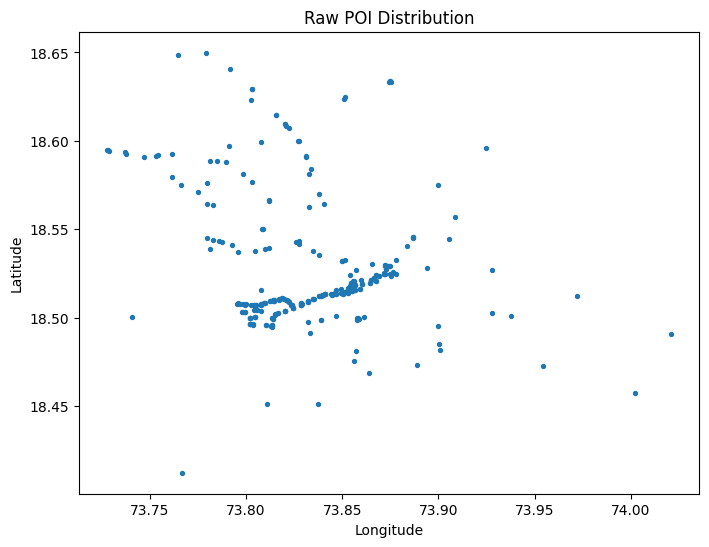

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(raw_df['lon'], raw_df['lat'], s=8)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Raw POI Distribution')
plt.show()

In [14]:
clean_df = raw_df.dropna(subset=['lat', 'lon'])

In [15]:
clean_df = clean_df.drop_duplicates(subset=['lat', 'lon'])

In [16]:
print('Before Cleaning:', len(raw_df))
print('After Cleaning:', len(clean_df))

Before Cleaning: 300
After Cleaning: 299


In [17]:
# Neighboorhood zones

coords = clean_df[['lat', 'lon']].values
geo_kmeans = KMeans(
    n_clusters=12, random_state=42, n_init=10
)

clean_df['geo_zone'] = geo_kmeans.fit_predict(coords)
clean_df.head()

,name,lat,lon,category,geo_zone
0,Shivajinagar,18.532248,73.849910,food,0
1,Pune Junction,18.528877,73.874415,food,0
2,Khadki,18.564172,73.840453,food,8
3,Kasarwadi,18.608093,73.820868,food,8
4,Shivajinagar,18.532591,73.851311,food,0


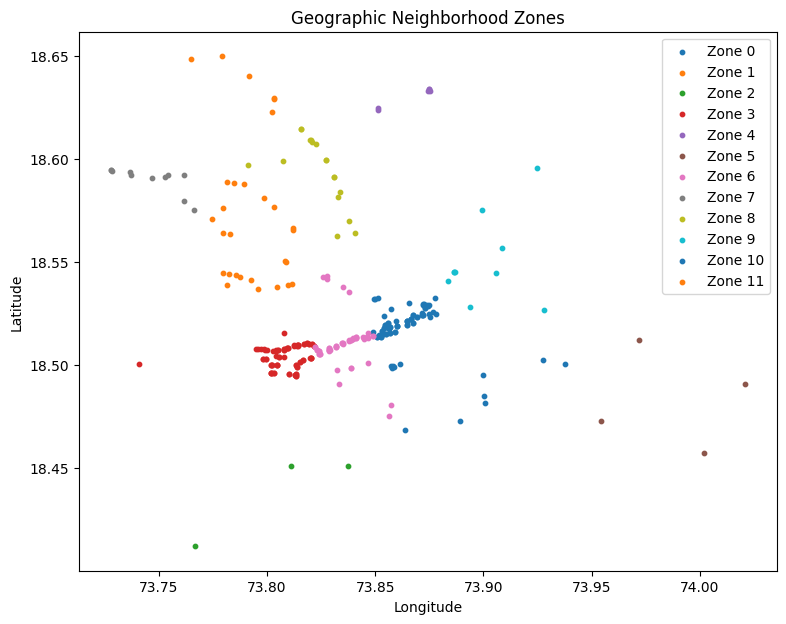

In [18]:
plt.figure(figsize=(9,7))

for cluster in sorted(clean_df['geo_zone'].unique()):
    subset = clean_df[clean_df['geo_zone'] == cluster]

    plt.scatter(
        subset['lon'],
        subset['lat'],
        s=10,
        label=f'Zone {cluster}'
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Neighborhood Zones')
plt.legend()
plt.show()

👆 This showed that spatial clustering naturally forms dense urban regions. These zones will be later used as neighboorhood units for feature aggregation.

In [19]:
# Aggregate POIs into neighboorhood features

zone_features = []

for zone_id in sorted(clean_df['geo_zone'].unique()):

    zone_df = clean_df[clean_df['geo_zone'] == zone_id]

    feature_row = {
        'zone_id': zone_id,
        'food_count': len(zone_df[zone_df['category'] == 'food']),
        'health_count': len(zone_df[zone_df['category'] == 'health']),
        'green_count': len(zone_df[zone_df['category'] == 'green']),
        'education_count': len(zone_df[zone_df['category'] == 'education']),
        'finance_count': len(zone_df[zone_df['category'] == 'finance']),
        'shopping_count': len(zone_df[zone_df['category'] == 'shopping']),
        'transit_count': len(zone_df[zone_df['category'] == 'transit']),
        'total_pois': len(zone_df),
        'center_lat': zone_df['lat'].mean(),
        'center_lon': zone_df['lon'].mean(),
    }

    zone_features.append(feature_row)

zones_df = pd.DataFrame(zone_features)

zones_df.head()

,zone_id,food_count,health_count,green_count,education_count,finance_count,shopping_count,transit_count,total_pois,center_lat,center_lon
0,0,75,0,0,0,0,0,0,75,18.520092,73.861933
1,1,23,0,0,0,0,0,0,23,18.558185,73.793398
2,2,3,0,0,0,0,0,0,3,18.438203,73.805063
3,3,80,0,0,0,0,0,0,80,18.504111,73.808570
4,4,6,0,0,0,0,0,0,6,18.630382,73.866960


In [20]:
zones_df.describe()

,zone_id,food_count,health_count,green_count,education_count,finance_count,shopping_count,transit_count,total_pois,center_lat,center_lon
count,12.000000,12.000000,12.0,12.0,12.0,12.0,12.0,12.0,12.000000,12.000000,12.000000
mean,5.500000,24.916667,0.0,0.0,0.0,0.0,0.0,0.0,24.916667,18.541920,73.843530
std,3.605551,28.618044,0.0,0.0,0.0,0.0,0.0,0.0,28.618044,0.062040,0.064903
min,0.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,18.438203,73.745659
25%,2.750000,6.000000,0.0,0.0,0.0,0.0,0.0,0.0,6.000000,18.499750,73.802146
50%,5.500000,10.500000,0.0,0.0,0.0,0.0,0.0,0.0,10.500000,18.535251,73.829741
75%,8.250000,31.500000,0.0,0.0,0.0,0.0,0.0,0.0,31.500000,18.591107,73.875308
max,11.000000,80.000000,0.0,0.0,0.0,0.0,0.0,0.0,80.000000,18.636734,73.987354


## Scaling
KMeans uses Euclidean distance.
Without normalization - large-value features dominate clustering & smaller features become insignificant.
Therefore, feature scaling is required.

In [21]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(zones_df)

scaled_df = pd.DataFrame(X_scaled, columns=zones_df.columns)
scaled_df.head()

,zone_id,food_count,health_count,green_count,education_count,finance_count,shopping_count,transit_count,total_pois,center_lat,center_lon
0,0.000000,0.935065,0.0,0.0,0.0,0.0,0.0,0.0,0.935065,0.412478,0.481077
1,0.090909,0.259740,0.0,0.0,0.0,0.0,0.0,0.0,0.259740,0.604349,0.197516
2,0.181818,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.245778
3,0.272727,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.331982,0.260288
4,0.363636,0.038961,0.0,0.0,0.0,0.0,0.0,0.0,0.038961,0.968007,0.501874


In [22]:
zones_df.describe()

,zone_id,food_count,health_count,green_count,education_count,finance_count,shopping_count,transit_count,total_pois,center_lat,center_lon
count,12.000000,12.000000,12.0,12.0,12.0,12.0,12.0,12.0,12.000000,12.000000,12.000000
mean,5.500000,24.916667,0.0,0.0,0.0,0.0,0.0,0.0,24.916667,18.541920,73.843530
std,3.605551,28.618044,0.0,0.0,0.0,0.0,0.0,0.0,28.618044,0.062040,0.064903
min,0.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,18.438203,73.745659
25%,2.750000,6.000000,0.0,0.0,0.0,0.0,0.0,0.0,6.000000,18.499750,73.802146
50%,5.500000,10.500000,0.0,0.0,0.0,0.0,0.0,0.0,10.500000,18.535251,73.829741
75%,8.250000,31.500000,0.0,0.0,0.0,0.0,0.0,0.0,31.500000,18.591107,73.875308
max,11.000000,80.000000,0.0,0.0,0.0,0.0,0.0,0.0,80.000000,18.636734,73.987354


In [23]:
scaled_df.describe()

,zone_id,food_count,health_count,green_count,education_count,finance_count,shopping_count,transit_count,total_pois,center_lat,center_lon
count,12.000000,12.000000,12.0,12.0,12.0,12.0,12.0,12.0,12.000000,12.000000,12.000000
mean,0.500000,0.284632,0.0,0.0,0.0,0.0,0.0,0.0,0.284632,0.522422,0.404934
std,0.327777,0.371663,0.0,0.0,0.0,0.0,0.0,0.0,0.371663,0.312494,0.268535
min,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,0.250000,0.038961,0.0,0.0,0.0,0.0,0.0,0.0,0.038961,0.310014,0.233713
50%,0.500000,0.097403,0.0,0.0,0.0,0.0,0.0,0.0,0.097403,0.488834,0.347884
75%,0.750000,0.370130,0.0,0.0,0.0,0.0,0.0,0.0,0.370130,0.770177,0.536414
max,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,1.000000


# Evaluating K values
KMeans require the number of clusters beforehand.
Choosing K arbitrarily can produce unstable segmentation, overlapping neighboorhoods and misleading tiers.
The goal is to identify the cluster count that maximizes separation, minimizes overlap and produces interpretable neighboorhood groups.

# Metrics
- Inertia - measures compactness
- Silhouette score - measure separation quality
- Davies Boulding Score - measure overlap

In [26]:
FEATURE_COLS = [
    'food_count',
    'transit_count',
    'health_count',
    'green_count',
    'education_count',
    'finance_count',
    'shopping_count'
]

X = zones_df[FEATURE_COLS].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
k_values = range(2,8)

inertias = []
silhouette_scores = []
db_scores = []

results = []

for k in k_values:

    print(f"\nEvaluating K = {k}")

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    inertias.append(inertia)

    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)

    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    db_scores.append(db_score)

    results.append({
        "K": k,
        "Inertia": round(inertia, 3),
        "Silhouette": round(sil_score, 4),
        "Davies_Bouldin": round(db_score, 4)
    })

    print(f"Inertia: {inertia:.3f}")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Score: {db_score:.4f}")



Evaluating K = 2
Inertia: 0.107
Silhouette Score: 0.8369
Davies-Bouldin Score: 0.2307

Evaluating K = 3
Inertia: 0.060
Silhouette Score: 0.7492
Davies-Bouldin Score: 0.1180

Evaluating K = 4
Inertia: 0.014
Silhouette Score: 0.6287
Davies-Bouldin Score: 0.2584

Evaluating K = 5
Inertia: 0.007
Silhouette Score: 0.5614
Davies-Bouldin Score: 0.2663

Evaluating K = 6
Inertia: 0.004
Silhouette Score: 0.5117
Davies-Bouldin Score: 0.1896

Evaluating K = 7
Inertia: 0.002
Silhouette Score: 0.3863
Davies-Bouldin Score: 0.1368


In [29]:
results_df = pd.DataFrame(results)

results_df

,K,Inertia,Silhouette,Davies_Bouldin
0,2,0.107,0.8369,0.2307
1,3,0.060,0.7492,0.1180
2,4,0.014,0.6287,0.2584
3,5,0.007,0.5614,0.2663
4,6,0.004,0.5117,0.1896
5,7,0.002,0.3863,0.1368


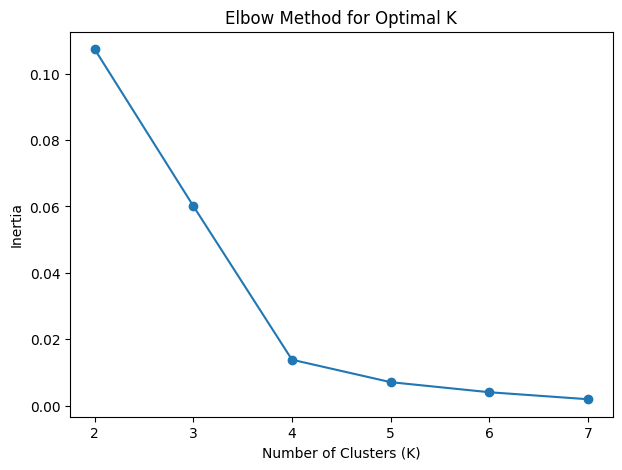

In [30]:
plt.figure(figsize=(7,5))

plt.plot(
    list(k_values),
    inertias,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

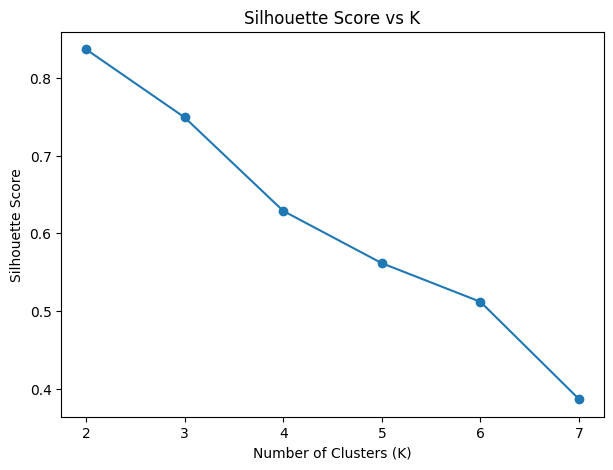

In [31]:
plt.figure(figsize=(7,5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()

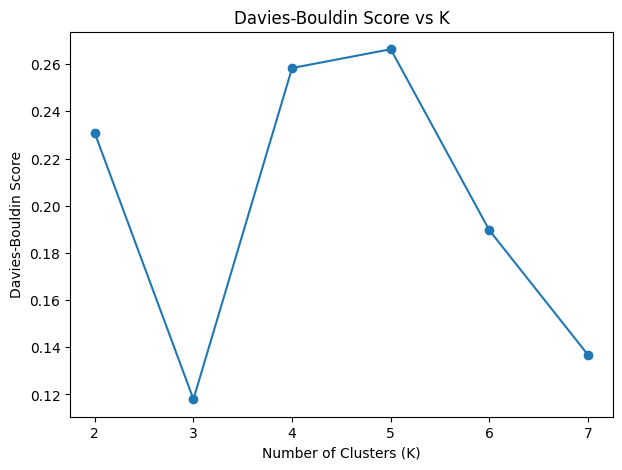

In [32]:
plt.figure(figsize=(7,5))

plt.plot(
    list(k_values),
    db_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score vs K")

plt.show()

In [33]:
best_index = silhouette_scores.index(max(silhouette_scores))

optimal_k = list(k_values)[best_index]

print("Optimal K:", optimal_k)

Optimal K: 2
